In [1]:
import os
# Change native directory to root
os.chdir(os.path.dirname(os.getcwd()))
os.chdir(os.path.dirname(os.getcwd()))

In [2]:
import pandas as pd
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
import pickle as pkl
import joblib as joblib
features = ['Month', 'Hour', 'hour_x', 'hour_y', 'month_x', 'month_y',
'net_target-23', 'diffuse_solar_radiation+1', 'direct_solar_radiation+1', 'relative_humidity+1', 'drybulb_temp+1']
target = 'net_target'

In [3]:
forecast = pd.read_csv('data/together_forecast/phase_3_forecast_sampled_1h.csv')
forecast

,time_step,scenario,building,+0h,+1h,+2h,+3h,+4h,+5h,+6h,...,+14h,+15h,+16h,+17h,+18h,+19h,+20h,+21h,+22h,+23h
0,0,0,0,1.108159,0.952937,0.895037,0.836170,0.809857,0.839004,0.687108,...,-0.691382,0.266271,0.711764,1.231934,1.512884,1.355655,1.413401,1.406286,1.455585,1.238483
1,0,0,1,0.323291,0.509660,0.571488,0.594606,0.636847,0.674240,0.591666,...,-0.669968,0.280011,0.681627,1.181309,1.433856,1.314948,1.343285,1.291011,1.234908,0.859436
2,0,0,2,1.130895,0.952937,0.895037,0.836170,0.809857,0.839004,0.687108,...,-0.691382,0.266105,0.711912,1.231934,1.512884,1.354668,1.413401,1.406286,1.455585,1.238739
3,0,0,3,0.529871,0.643276,0.657891,0.681886,0.694483,0.722720,0.590283,...,-0.674543,0.260035,0.671301,1.186248,1.439446,1.337567,1.366263,1.302416,1.267724,0.989886
4,0,0,4,0.323291,0.509660,0.571488,0.594606,0.636847,0.674240,0.591666,...,-0.669968,0.280011,0.681627,1.181309,1.433856,1.314948,1.343285,1.291011,1.234908,0.859436
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61315,8759,0,2,0.698066,0.596489,0.547631,0.554751,0.560215,0.468894,0.512191,...,-1.598829,-0.991041,-1.177272,-0.808569,-0.116398,0.793366,0.773687,1.063134,0.944060,0.766505
61316,8759,0,3,0.983195,0.507087,0.581777,0.519443,0.380425,0.318427,0.315241,...,0.691031,0.955694,1.015017,1.333128,2.175574,1.412085,1.500392,1.025895,1.145050,1.534916
61317,8759,0,4,0.304050,0.117322,0.197688,0.197372,0.275058,0.246635,0.405497,...,2.442411,2.628395,1.933629,1.819645,1.252357,0.301022,0.345424,0.290214,0.276149,0.250423
61318,8759,0,5,1.253717,1.243149,1.231042,1.171024,1.297621,1.345405,1.371322,...,-1.018511,-0.238978,0.460956,0.866744,1.105025,2.372571,2.746750,2.278559,1.893020,1.488648


In [ ]:
power = pd.read_csv('data/citylearn_challenge_2022_phase_3/perfect_mpc_24_no_grid_cost.csv')

In [12]:
power

,time_step,scenario,building,+0h,+1h,+2h,+3h,+4h,+5h,+6h,...,+14h,+15h,+16h,+17h,+18h,+19h,+20h,+21h,+22h,+23h
0,0,0,0,1.108159,0.952937,0.895037,0.836170,0.809857,0.839004,0.687108,...,-0.691382,0.266271,0.711764,1.231934,1.512884,1.355655,1.413401,1.406286,1.455585,1.238483
1,0,0,1,0.323291,0.509660,0.571488,0.594606,0.636847,0.674240,0.591666,...,-0.669968,0.280011,0.681627,1.181309,1.433856,1.314948,1.343285,1.291011,1.234908,0.859436
2,0,0,2,1.130895,0.952937,0.895037,0.836170,0.809857,0.839004,0.687108,...,-0.691382,0.266105,0.711912,1.231934,1.512884,1.354668,1.413401,1.406286,1.455585,1.238739
3,0,0,3,0.529871,0.643276,0.657891,0.681886,0.694483,0.722720,0.590283,...,-0.674543,0.260035,0.671301,1.186248,1.439446,1.337567,1.366263,1.302416,1.267724,0.989886
4,0,0,4,0.323291,0.509660,0.571488,0.594606,0.636847,0.674240,0.591666,...,-0.669968,0.280011,0.681627,1.181309,1.433856,1.314948,1.343285,1.291011,1.234908,0.859436
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61315,8759,0,2,0.698066,0.596489,0.547631,0.554751,0.560215,0.468894,0.512191,...,-1.598829,-0.991041,-1.177272,-0.808569,-0.116398,0.793366,0.773687,1.063134,0.944060,0.766505
61316,8759,0,3,0.983195,0.507087,0.581777,0.519443,0.380425,0.318427,0.315241,...,0.691031,0.955694,1.015017,1.333128,2.175574,1.412085,1.500392,1.025895,1.145050,1.534916
61317,8759,0,4,0.304050,0.117322,0.197688,0.197372,0.275058,0.246635,0.405497,...,2.442411,2.628395,1.933629,1.819645,1.252357,0.301022,0.345424,0.290214,0.276149,0.250423
61318,8759,0,5,1.253717,1.243149,1.231042,1.171024,1.297621,1.345405,1.371322,...,-1.018511,-0.238978,0.460956,0.866744,1.105025,2.372571,2.746750,2.278559,1.893020,1.488648


In [333]:
# for the matching time steps, merge the forecast and power dataframes
forecast = forecast.merge(power, how='inner', on=['time_step', 'building'])

In [334]:
forecast

,time_step,scenario,building,+1h,+2h,+3h,+4h,+5h,+6h,+7h,...,net_load+15,net_load+16,net_load+17,net_load+18,net_load+19,net_load+20,net_load+21,net_load+22,net_load+23,net_load+24
0,0,0,0,0.737881,0.344792,-0.100352,-0.039405,0.038974,0.026710,-0.667358,...,-0.298267,0.059700,1.054850,1.006983,3.603983e+00,5.008500e+00,3.896217e+00,3.557083e+00,1.411333e+00,9.794167e-01
1,0,0,1,0.519483,0.199971,-0.129194,-0.063702,-0.103141,-0.112332,-0.632428,...,0.204017,-0.572450,-0.678733,-0.069417,3.583334e-01,1.584500e+00,2.561233e+00,1.434200e+00,4.132075e+00,2.900917e+00
2,0,0,2,-0.332168,-0.602513,-0.842794,-0.801691,-0.748832,-0.757103,-1.225185,...,-1.743550,-1.656633,-0.879733,-0.045600,1.011848e-07,1.003265e-07,1.000817e-07,1.015007e-07,1.034101e-07,9.991129e-08
3,0,0,3,0.732954,-0.142657,-0.383004,-0.613359,-0.601909,-0.610345,-1.087744,...,-2.074017,-0.055433,0.160417,0.149917,1.557933e+00,2.832317e+00,6.387667e-01,7.265167e-01,2.649125e+00,4.703167e-01
4,0,0,4,0.079354,-0.215069,-0.492037,-0.499149,-0.535429,-0.543883,-1.022317,...,-0.137150,0.023717,2.313683,1.957267,1.498883e+00,2.606917e+00,1.278900e+00,1.098700e+00,1.060992e+00,3.063000e-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43766,8757,0,3,1.268422,1.322211,1.410212,1.260994,1.180815,0.858036,0.739260,...,-1.810483,-0.152117,-0.109050,-0.137150,2.371667e-02,2.313683e+00,1.957267e+00,1.498883e+00,2.606917e+00,1.278900e+00
43767,8758,0,0,1.961151,1.836744,0.957034,0.785600,0.748177,0.768787,0.779483,...,0.924617,0.935333,0.204017,-0.572450,-6.787332e-01,-6.941661e-02,3.583334e-01,1.584500e+00,2.561233e+00,1.434200e+00
43768,8758,0,1,1.836834,1.774316,0.654268,0.697268,0.723909,0.821337,0.655283,...,-1.296567,-1.413883,-1.743550,-1.656633,-8.797332e-01,-4.559990e-02,1.011848e-07,1.003265e-07,1.000817e-07,1.015007e-07
43769,8758,0,2,0.912556,0.754576,0.471826,0.399083,0.330931,0.312721,0.299903,...,-2.687133,-1.972850,-2.074017,-0.055433,1.604167e-01,1.499167e-01,1.557933e+00,2.832317e+00,6.387667e-01,7.265167e-01


In [336]:
# substact the forecast from the real power
for i in range(1, 25):
    forecast[f'error+{i}'] = forecast[f'net_load+{i}'] - forecast[f'+{i}h']

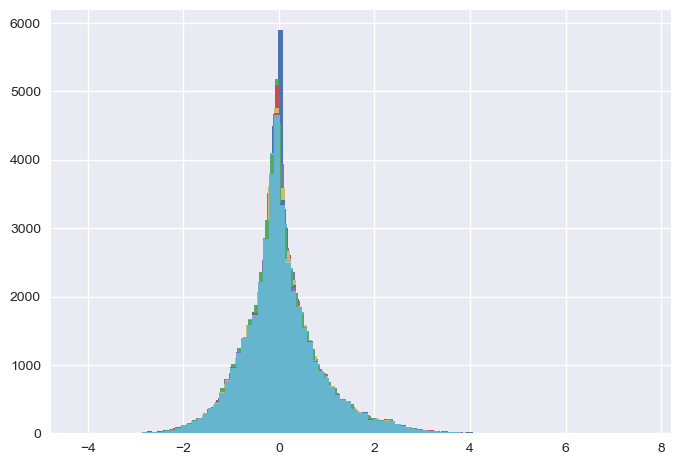

In [344]:
# plot distribution of error+1
for i in range(1, 25):
    plt.hist(forecast[f'error+{i}'], bins=100)
plt.show()